In [70]:
import torch
import torch.nn as nn 
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

In [71]:
# 복잡한 데이터 (차수가 많은), 복잡한 모델(고차원 모델), 작은양의 데이터()
# 과적합
# 데이터 수 늘리기 (현실적으로 불가능), 복잡한 모델 단순화 (히든 레이어, 뉴런 출아)
# 드랍아웃과 같은 별도의 규제 레이어 추가
# 학습이 잘 되도록 하는 정규화 레이어 추가

In [72]:
def create_complex_dataset(n_samples=1200):
    X = torch.randn(n_samples, 20)
    # 비선형 및 노이즈 추가
    y = (torch.sin(X[:, 0] * 2) + X[:, 1]*2 - torch.abs(X[:, 2]) + torch.randn(n_samples)*0.1).reshape(-1, 1)
    # 정규화
    y = (y - y.mean()) / y.std()
    return TensorDataset(X, y)

dataset = create_complex_dataset()
train_size = int(0.1*len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=12, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=12)

# Early stopping 클래스
- 검증 손실이 개선되지 않을 때 학습률 검증

In [92]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, path='best_model.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.best_loss = float('inf')
        self.early_stop = False
        self.counter = 0
    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


# 모델정의(Dropout & Batch Normalization 적용)

In [74]:
x_batch, y_batch = next(iter(train_loader))
x_batch.shape,  y_batch.shape

(torch.Size([12, 20]), torch.Size([12, 1]))

In [75]:
class AdvenceModel(nn.Module):
    def __init__(self, input_dim, dropout_p=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 120),
            nn.ReLU(),

            nn.Linear(120, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)
    
model = AdvenceModel(input_dim=20)
print(model)

AdvenceModel(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=120, bias=True)
    (1): ReLU()
    (2): Linear(in_features=120, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


# 학습루프 (시각화)
- 옵티마이저, 손실함수 : 필수
- early stopping : 옵션

In [76]:
from tqdm import tqdm
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion =  nn.MSELoss()
early_stopping = EarlyStopping(patience=5)

epochs = 200
train_loss = []; val_loss = []
pbar = tqdm(range(epochs))
for epoch in pbar:
    batch_train_losses = 0.0 ; batch_val_losses=0.0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        batch_train_losses += loss.item()
    train_loss.append( batch_train_losses / len(train_loader) )
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            output = model(batch_x)
            loss = criterion(output, batch_y)
            batch_val_losses += loss.item()
        val_loss.append( batch_val_losses / len(val_loader) )
    pbar.set_postfix({'Train': f'{train_loss[-1]:.4f}', 
                  'Val': f'{val_loss[-1]:.4f}'})
    
    if (epoch+1) % 10 == 0 or epoch == 0:
        tqdm.write(f'epoch {epoch+1} / {epochs} train loss: {train_loss[-1]:.4f} val loss: {val_loss[-1]:.4f}')


  2%|▏         | 3/200 [00:00<00:06, 29.73it/s, Train=0.2335, Val=0.2876]

epoch 1 / 200 train loss: 1.1095 val loss: 0.9134


  8%|▊         | 15/200 [00:00<00:05, 33.12it/s, Train=0.0154, Val=0.2434]

epoch 10 / 200 train loss: 0.0577 val loss: 0.2379


 13%|█▎        | 26/200 [00:00<00:05, 29.95it/s, Train=0.0017, Val=0.2404]

...

epoch 180 / 200 train loss: 0.0001 val loss: 0.2333


 96%|█████████▋| 193/200 [00:06<00:00, 29.53it/s, Train=0.0000, Val=0.2329]

epoch 190 / 200 train loss: 0.0000 val loss: 0.2329


100%|██████████| 200/200 [00:06<00:00, 30.01it/s, Train=0.0000, Val=0.2330]

epoch 200 / 200 train loss: 0.0000 val loss: 0.2330


# 시각화

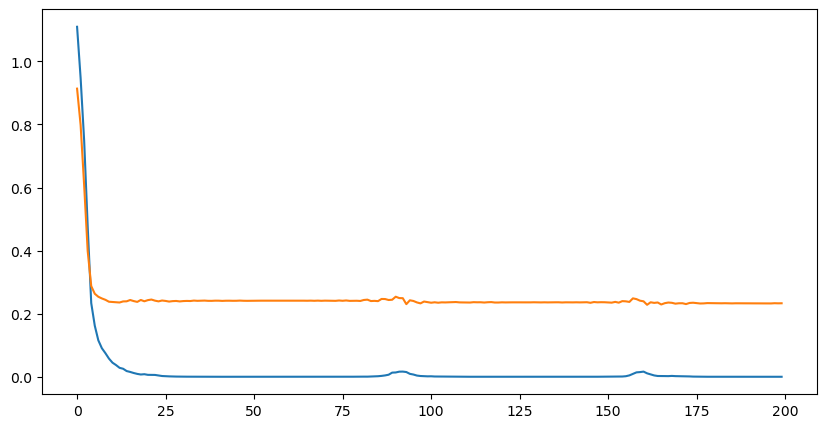

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(range(epochs), train_loss, label='train_loss')
plt.plot(range(epochs), val_loss, label='val_loss')
plt.legend()
plt.show()

# 규제(dropout) 정규화, ealy sotopping

In [85]:
new_layers = []
model = AdvenceModel(input_dim=20)
for i, layer in enumerate(list(model.network)):
    new_layers.append(layer)
    if isinstance(layer, nn.Linear) and i < len( list(model.network))-1:        
        new_layers.append(nn.BatchNorm1d( layer.out_features ))
        new_layers.append(nn.Dropout(0.3))
    if isinstance(layer, nn.ReLU):
        new_layers.append(nn.Dropout(0.5))

new_model = nn.Sequential(*new_layers)
new_model

Sequential(
  (0): Linear(in_features=20, out_features=120, bias=True)
  (1): BatchNorm1d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): Dropout(p=0.3, inplace=False)
  (3): ReLU()
  (4): Dropout(p=0.5, inplace=False)
  (5): Linear(in_features=120, out_features=64, bias=True)
  (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): Dropout(p=0.3, inplace=False)
  (8): ReLU()
  (9): Dropout(p=0.5, inplace=False)
  (10): Linear(in_features=64, out_features=32, bias=True)
  (11): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): Dropout(p=0.3, inplace=False)
  (13): ReLU()
  (14): Dropout(p=0.5, inplace=False)
  (15): Linear(in_features=32, out_features=1, bias=True)
)

In [95]:
from tqdm import tqdm
optimizer = optim.Adam(new_model.parameters(), lr=1e-3)
criterion =  nn.MSELoss()
early_stopping = EarlyStopping(patience=7)

epochs = 2000
train_loss = []; val_loss = []
pbar = tqdm(range(epochs))

best_epoch = 0
for epoch in pbar:
    new_model.train()  # 드랍아웃과 배치정규화가 학습 및 평가할때 서로 다르게 동작하는걸 방지
    batch_train_losses = 0.0 ; batch_val_losses=0.0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        output = new_model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        batch_train_losses += loss.item()    
    
    new_model.eval()
    with torch.no_grad(): # 불필요한 업데이트 방지(메모리 절약)
        for batch_val_x, batch_val_y in val_loader:            
            output = new_model(batch_val_x)
            loss = criterion(output, batch_val_y)            
            batch_val_losses += loss.item()            
            
    train_loss.append( batch_train_losses / len(train_loader) )
    val_loss.append(batch_val_losses / len(val_loader))    
    pbar.set_postfix({'Train' : f'{train_loss[-1]:.4f}',  'val' : f'{val_loss[-1]:.4f}'})

    if (epoch+1) % 20 == 0 or epoch == 0:
        tqdm.write(f'epoch {epoch+1} / {epochs} train loss : {train_loss[-1]:.4f}  val loss : {val_loss[-1]:.4f}')
    
    early_stopping(val_loss[-1],new_model)
    if early_stopping.early_stop:
        print(f'ealy stopping {train_loss[-1]:.4f} val loss : {val_loss[-1]:.4f}')
        best_epoch = epoch
        break

  0%|          | 2/2000 [00:00<02:27, 13.59it/s, Train=0.4134, val=0.2570]

epoch 1 / 2000 train loss : 0.3189  val loss : 0.2406


  0%|          | 7/2000 [00:00<02:52, 11.56it/s, Train=0.3162, val=0.2777]

ealy stopping 0.3162 val loss : 0.2777


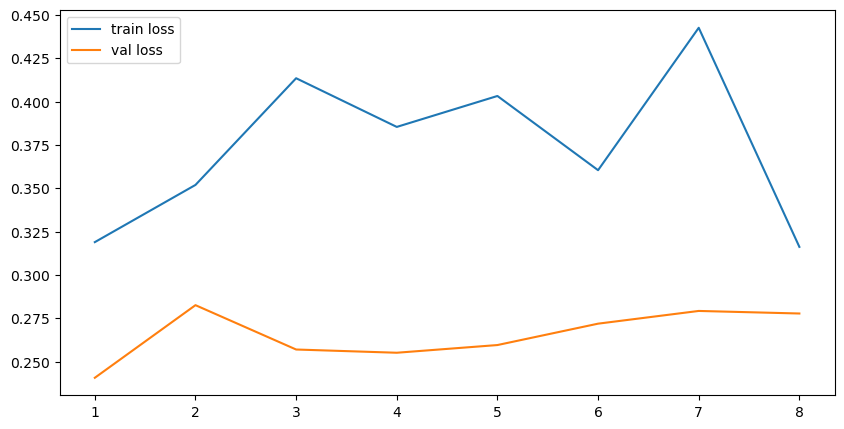

In [96]:
fig, ax = plt.subplots(figsize=(10,5))
plt.plot(range(1,best_epoch+2), train_loss, label = 'train loss')
plt.plot(range(1,best_epoch+2), val_loss, label = 'val loss')
plt.legend()
plt.show()